In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as colors

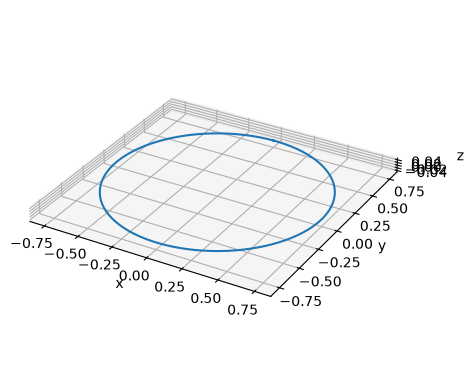

In [3]:
'''
Define a class for a current carrying curve (i.e., the shape of a wire)

This will be used to make defining a curve super easy and generating its points in 3D space, 
and displaying the curve

This models a simple loop, but can define additional loops to model an infinitely thin and short coil.
This can approximate a coil with lots of turns
'''


class current_curve():
    def __init__(self, center, normal, r, turns, n=100):
        self.center = np.array(center)
        normal = normal/np.linalg.norm(normal)
        self.normal = np.array(normal)
        self.r = float(r)
        self.turns = float(turns)
        self.n = float(n)
        
        guess = np.array((1, 0, 0))
        threshold = 15 / (180 / np.pi) # convert to radians        
        if np.arccos(np.dot(normal, guess)) < threshold or np.arccos(np.dot(normal, guess)) > np.pi - threshold:
            guess = np.array((0, 1, 0))

        u = np.cross(normal, guess)
        u = u/np.linalg.norm(u)

        v = np.cross(normal, u)

        c_points = []
        t = np.linspace(0, 2*np.pi, n)
        for i in t:
            point = center + r*np.cos(i)*u + r*np.sin(i)*v
            c_points.append(point)
        self.points = np.array(c_points)
        
    def plot_curve(self, ax=plt.figure().add_subplot(projection='3d'), show_normal=False):
        coords = np.rot90(self.points, k=3)

        ax.plot(coords[0], coords[1], coords[2])

        if show_normal:
            ax.quiver(self.center[0], self.center[1], self.center[2],
                    self.normal[0], self.normal[1], self.normal[2])
        ax.set_aspect('equal')
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.set_zlabel('z')

    def get_size(self):

        coords = np.rot90(self.points, k=3)
        result = []
        for i in range(0, 3):
            result.append((min(coords[i]), max(coords[i])))

        return np.array(result)

c1 = current_curve((0, 0, 0), (0, 0, 1), 0.75, 5)
c1.plot_curve()

In [4]:
'''
Class for magnetic fields resulting from current carrying curves


'''

class field():
    def __init__(self, curves, currents):
        self.curves = curves
        self.currents = currents

        self.vector_field = None
        self.point_field = None
        self.mag_field = None

        self.axis_points = None

    def generate_points(self, point_ranges, n=(10, 10, 10)):
        '''
        point_ranges (2 x 3) - point min/max for each axis
        n (tuple, 1 x 3) - number of points per axis
        '''

        x = np.linspace(point_ranges[0][0], point_ranges[0][1], n[0])
        y = np.linspace(point_ranges[1][0], point_ranges[1][1], n[1])
        z = np.linspace(point_ranges[2][0], point_ranges[2][1], n[2])

        xv, yv, zv = np.meshgrid(x, y, z)

        self.axis_points = [x, y, z]

        xl = xv.ravel()
        yl = yv.ravel()
        zl = zv.ravel()
        points = []
        for k in range(0, len(xl)):
            points.append((xl[k], yl[k], zl[k]))
        
        return np.array(points)
    
    def combine_ranges(self, a, b):
        '''
        takes in 2 x n arrays
        finds the min of the left value and the max of the right value in each row
        '''
        for i, row in enumerate(a):
            a[i] = (min(row[0], b[i][0]), max(row[1], b[i][1]))
        return np.array(a)

    def generate_point_field(self, n=10, padding=2):
        '''
        n - number of points per axis, total points is n^3
        padding - added space around curve bounding box to generate points, in same units as curve
        '''
        pad = []
        for i in range(0, 3):
            pad.append((padding*-1, padding))
        pad = np.array(pad)
        
        point_ranges = self.curves[0].get_size()
        for curve in self.curves:
            point_ranges = self.combine_ranges(curve.get_size(), point_ranges)
            # make this function iterate over curves and find the min/max of all of them
        point_ranges = point_ranges + pad
        
        self.point_field = self.generate_points(point_ranges, (n, n, n))
    
    def generate_point_slice(self, axis='x', slice_point=0, n=10, padding=2):
        '''
        n - number of points per axis, total points is n^2
        padding - added space around curve bounding box to generate points, in same units as curve
        '''
        pad = []
        for i in range(0, 3):
            pad.append((padding*-1, padding))
        pad = np.array(pad)
        
        point_ranges = self.curves[0].get_size()
        for curve in self.curves:
            point_ranges = self.combine_ranges(curve.get_size(), point_ranges)
            # make this function iterate over curves and find the min/max of all of them
        point_ranges = point_ranges + pad

        ns = np.array((n, n, n))

        match axis:
            case 'x':
                index = 0
            case 'y':
                index = 1
            case 'z':
                index = 2
            case _:
                raise Exception('Axis nees to be within: x, y, z')
        
        ns[index] = 1
        point_ranges[index] = (slice_point, slice_point)
        
        self.point_field = self.generate_points(point_ranges, ns)

    def solve(self):

        # if no point field is generated, generate one
        if self.point_field is None:
            self.generate_point_field()

        field_result = np.zeros((len(self.point_field), 3))
        for i, curve in enumerate(self.curves):
            field_result_curve = []
            for point in self.point_field:
                point_result = self.b_field_point(self.currents[i]*curve.turns, point, curve.points, True)
                field_result_curve.append(point_result)
            field_result = np.add(field_result_curve, field_result)
        self.vector_field = np.array(field_result)

        mag_result = []
        for res in self.vector_field:
            mag_result.append(np.linalg.norm(res))
        self.mag_field = np.array(mag_result)
        
    def b_field_point(self, i, p, c, closed=False):
        '''
        Inputs
            i (float) - constant current in wire, in Amps
            p (array (1 x 3)) - point to calculate b field, in meters
            c (array (n x 3)) - array of current carrying curve points to integrate over, in meters
            closed (bool) - determines if curve is closed, defaults to false

        Outputs
            b (array (1 x 3)) - resulting b field for point, in Tesla
        '''

        u0 = np.pi*4*(10**-7)
        b = np.array((0, 0, 0))

        if closed:
            val = -1
        else:
            val = 0

        for j in range(val, len(c)-1):
            dL = np.subtract(c[j+1],c[j])
            r_p = np.subtract(p, c[j])
            b = np.add(np.cross(dL, r_p)/np.linalg.norm(r_p)**3, b)

        return np.multiply(u0*i/(4*np.pi), b)
    def plot_field(self):
        '''
        general plotting function
        plots 3d vector field
        '''
        
        ax = plt.figure().add_subplot(projection='3d')

        cmap = cm.viridis
        norm = colors.LogNorm(vmin=min(self.mag_field), vmax=max(self.mag_field), clip=True)
        mapper = cm.ScalarMappable(norm=norm, cmap=cmap)

        color_mag = mapper.to_rgba(self.mag_field)

        vector_coords = np.rot90(self.vector_field, 3)
        point_coords = np.rot90(self.point_field, 3)

        length = 0
        for i in range(0, 3):
            length = max(length, abs(point_coords[i][1] - point_coords[i][0]))

        ax.quiver(point_coords[0], point_coords[1], point_coords[2], 
                  vector_coords[0], vector_coords[1], vector_coords[2], 
                  color=color_mag, length=length, normalize=True)
        
        for curve in self.curves:
            curve.plot_curve(ax=ax)
        
        ax.set_aspect('equal')
        plt.colorbar(mappable=mapper, ax=ax)
    
    def plot_slice(self, axis):
        '''
        plotting function for slices only
        plots 2d streamlines of magnetic field along slice
        '''

        fig, ax = plt.subplots(1, 1)
        cmap = cm.viridis
        norm = colors.LogNorm(vmin=min(self.mag_field), vmax=max(self.mag_field), clip=True)
        mapper = cm.ScalarMappable(norm=norm, cmap=cmap)

        match axis:
            case 'x':
                indices = [1, 2]
                plt.xlabel('y')
                plt.ylabel('z')
            case 'y':
                indices = [0, 2]
                plt.xlabel('x')
                plt.ylabel('z')
            case 'z':
                indices = [0, 1]
                plt.xlabel('x')
                plt.ylabel('y')
            case _:
                raise Exception('Axis nees to be within: x, y, z')

        x, y = np.meshgrid(self.axis_points[indices[0]], self.axis_points[indices[1]])
        
        u = []
        v = []
        color_mag = []

        for vector in self.vector_field:
            u.append(vector[indices[0]])
            v.append(vector[indices[1]])
            color_mag.append(np.linalg.norm(vector))
        u = np.rot90(np.array(u).reshape(x.shape))
        v = np.rot90(np.array(v).reshape(x.shape))
        color_mag = np.rot90(np.array(color_mag).reshape(x.shape))
        u = np.flip(u, 0)
        v = np.flip(v, 0)
        color_mag = np.flip(color_mag, 0)

        shape = x.shape
        color = []
        for j in range(0, shape[1]):
            row = []
            for i in range(0, shape[0]):
                row.append(np.linalg.norm((u[i][j], v[i][j])))
            color.append(row)
        color = np.rot90(np.array(color))
        color = np.flip(color, 0)

        # color is for streamplot
        # color_mag is for contour

        ax.streamplot(x, y, u, v, color='k')
        ax.contourf(x, y, color_mag)
        plt.colorbar(mappable=mapper, ax=ax)


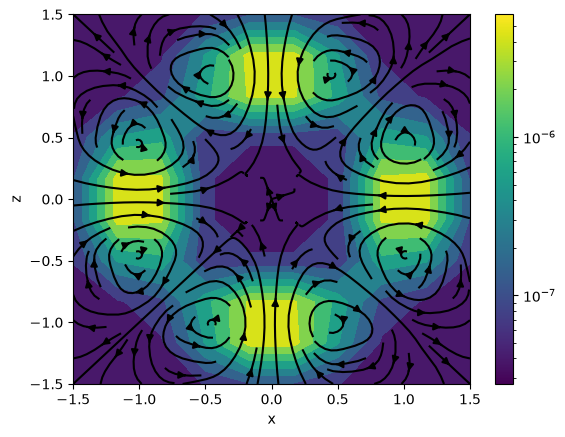

In [5]:
# 3 axis dual fields

r = 0.4
turns = 5
n = 20

c1 = current_curve((-1, 0, 0), (1, 0, 0), r, turns, n)
c2 = current_curve((1, 0, 0), (-1, 0, 0), r, turns, n)
c3 = current_curve((0, -1, 0), (0, 1, 0), r, turns, n)
c4 = current_curve((0, 1, 0), (0, -1, 0), r, turns, n)
c5 = current_curve((0, 0, -1), (0, 0, 1), r, turns, n)
c6 = current_curve((0, 0, 1), (0, 0, -1), r, turns, n)

f = field(curves=[c1, c2, c3, c4, c5, c6], currents=[1, 1, 1, 1, 1, 1])

axis = 'y'

f.generate_point_slice(axis=axis, slice_point=0, n=10, padding=0.5)
f.solve()
f.plot_slice(axis)

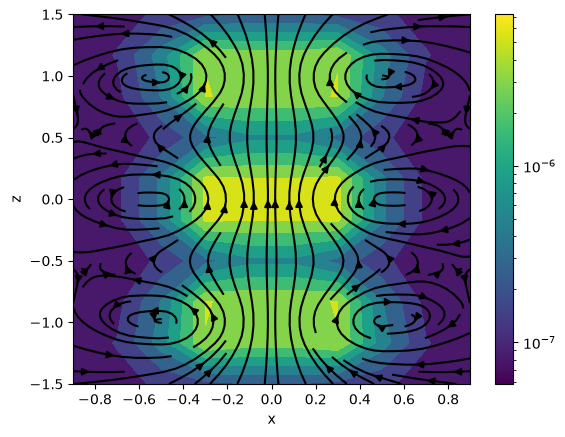

In [6]:
c1 = current_curve((0, 0, -1), (0, 0, 1), r, turns, n)
c2 = current_curve((0, 0, 0), (0, 0, 1), r, turns, n)
c3 = current_curve((0, 0, 1), (0, 0, 1), r, turns, n)


f = field(curves=[c1, c2, c3], currents=[1, 1, 1])

axis = 'y'

f.generate_point_slice(axis=axis, slice_point=0, n=10, padding=0.5)
f.solve()
f.plot_slice(axis)

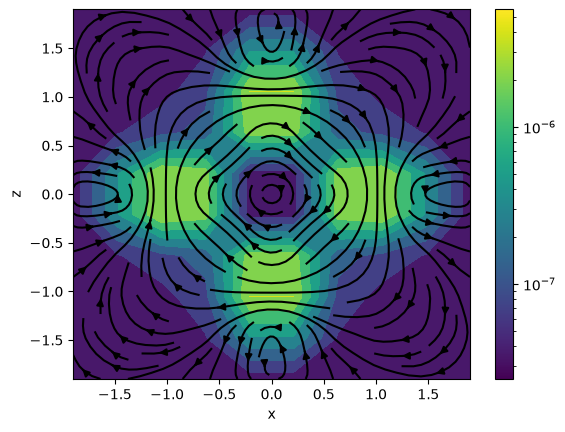

In [7]:
r = 0.4

c1 = current_curve((-1, 0, 0), (0, 0, 1), r, turns, n)
c2 = current_curve((1, 0, 0), (0, 0, -1), r, turns, n)
c3 = current_curve((0, 0, -1), (-1, 0, 0), r, turns, n)
c4 = current_curve((0, 0, 1), (1, 0, 0), r, turns, n)



f = field(curves=[c1, c2, c3, c4], currents=[1, 1, 1, 1])

axis = 'y'

f.generate_point_slice(axis=axis, slice_point=0, n=10, padding=0.5)
f.solve()
f.plot_slice(axis)

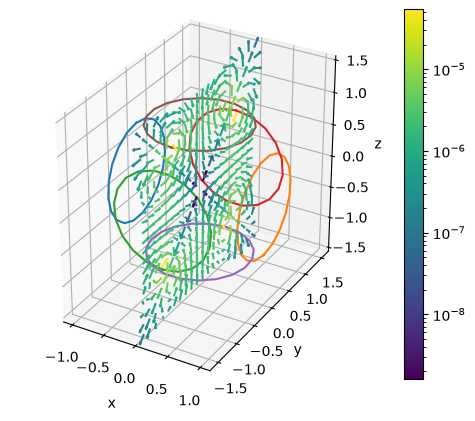

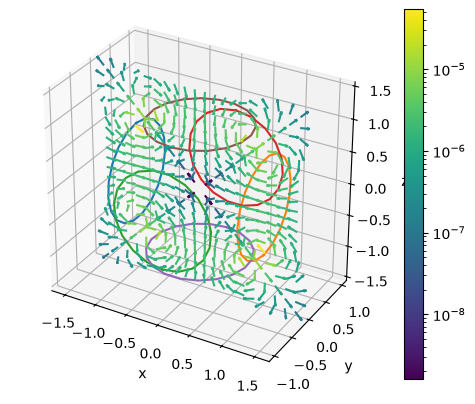

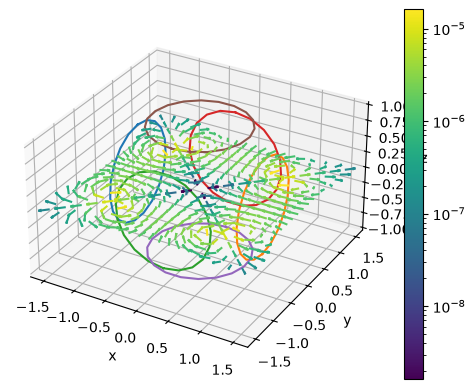

In [8]:
# 3 axis dual fields

r = 0.75
turns = 5
n = 20

c1 = current_curve((-1, 0, 0), (1, 0, 0), r, turns, n)
c2 = current_curve((1, 0, 0), (-1, 0, 0), r, turns, n)
c3 = current_curve((0, -1, 0), (0, 1, 0), r, turns, n)
c4 = current_curve((0, 1, 0), (0, -1, 0), r, turns, n)
c5 = current_curve((0, 0, -1), (0, 0, 1), r, turns, n)
c6 = current_curve((0, 0, 1), (0, 0, -1), r, turns, n)

f = field(curves=[c1, c2, c3, c4, c5, c6], currents=[1, 1, 1, 1, 1, 1])

for axis in ['x', 'y', 'z']:
    f.generate_point_slice(axis=axis, slice_point=0, n=20, padding=0.5)
    f.solve()
    f.plot_field()

In [10]:
a = np.array((1, 2, 3, 4, 5, 6, 7, 8))

print(a)

print(a.reshape((4, 2)))

#made a small change

[1 2 3 4 5 6 7 8]
[[1 2]
 [3 4]
 [5 6]
 [7 8]]
